In [ ]:

import glob
import pickle
import threading
from concurrent import futures
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    PrecisionRecallDisplay,
    accuracy_score,
    confusion_matrix,
    precision_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


In [ ]:

bad_names = []
bad_names_lock = threading.Lock()


def download_stock(stock, start_time, now_time):
    """Try to query yfinance for a stock, note failures."""
    try:
        print(f"Downloading: {stock}")
        stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)

        # yfinance returns MultiIndex columns (Ticker level) for some versions
        # even with a single symbol -- flatten them.
        if isinstance(stock_df.columns, pd.MultiIndex):
            stock_df.columns = stock_df.columns.get_level_values(0)

        if not stock_df.empty:
            stock_df["Name"] = stock
            stock_df.to_csv(f"{stock}_data.csv")
        else:
            with bad_names_lock:
                bad_names.append(stock)
            print(f"Empty data: {stock}")
    except Exception as e:
        with bad_names_lock:
            bad_names.append(stock)
        print(f"Bad: {stock} | Error: {e}")


if __name__ == "__main__":
    now_time = datetime.now()
    start_time = datetime(now_time.year - 5, now_time.month, now_time.day)

    s_and_p = [
        'MMM', 'ABT', 'ABBV', 'ACN', 'AYI', 'ADBE', 'AMD', 'AES',
        'AFL', 'A', 'APD', 'AKAM', 'ALK', 'ALB', 'ARE', 'ALLE', 'ADS', 'LNT',
        'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AEE', 'AAL', 'AEP', 'AXP',
        'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS',
        'AON', 'AOS', 'APA', 'AAPL', 'AMAT', 'APTV', 'ADM', 'AJG', 'AIZ',
        'T', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'BLL', 'BAC', 'BK', 'BAX',
        'BDX', 'BBY', 'BIIB', 'BLK', 'HRB', 'BA', 'BWA', 'BXP', 'BSX', 'BMY',
        'AVGO', 'CHRW', 'CDNS', 'CPB', 'COF', 'CAH', 'CBOE', 'KMX', 'CCL',
        'CAT', 'CBS', 'CNC', 'CNP', 'CERN', 'CF', 'SCHW', 'CHTR', 'CVX',
        'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CTXS',
        'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CMA', 'CAG',
        'COP', 'ED', 'STZ', 'COO', 'GLW', 'COST', 'COTY', 'CCI', 'CSX',
        'CMI', 'CVS', 'DHI', 'DHR', 'DRI', 'DVA', 'DE', 'DAL', 'XRAY',
        'DVN', 'DLR', 'DFS', 'DISH', 'DG', 'DLTR', 'D', 'DOV', 'DTE', 'DRE',
        'DUK', 'DXC', 'EMN', 'ETN', 'EBAY', 'ECL', 'EIX', 'EW', 'EA', 'EMR',
        'ETR', 'EOG', 'EQT', 'EFX', 'EQIX', 'EQR', 'ESS', 'EL', 'ES', 'RE',
        'EXC', 'EXPE', 'EXPD', 'EXR', 'XOM', 'FFIV', 'FAST', 'FRT', 'FDX',
        'FIS', 'FITB', 'FE', 'FISV', 'FLIR', 'FLS', 'FLR', 'FMC', 'FL', 'F',
        'FTV', 'FBHS', 'BEN', 'FCX', 'GPS', 'GRMN', 'IT', 'GD', 'GE', 'GIS',
        'GM', 'GPC', 'GILD', 'GPN', 'GS', 'GT', 'GWW', 'HAL', 'HBI', 'HOG',
        'HIG', 'HAS', 'HCA', 'HP', 'HSIC', 'HSY', 'HES', 'HPE', 'HLT',
        'HOLX', 'HD', 'HON', 'HRL', 'HST', 'HPQ', 'HUM', 'HBAN', 'HII',
        'IDXX', 'ITW', 'ILMN', 'IR', 'INTC', 'ICE', 'IBM', 'INCY', 'IP',
        'IPG', 'IFF', 'INTU', 'ISRG', 'IVZ', 'IQV', 'IRM', 'JBHT', 'SJM',
        'JNJ', 'JCI', 'JPM', 'JNPR', 'KSU', 'K', 'KEY', 'KMB', 'KIM', 'KMI',
        'KLAC', 'KSS', 'KHC', 'KR', 'LB', 'LH', 'LRCX', 'LEG', 'LEN', 'LLY',
        'LNC', 'LKQ', 'LMT', 'L', 'LOW', 'LYB', 'MTB', 'MAC', 'M', 'MRO',
        'MPC', 'MAR', 'MMC', 'MLM', 'MAS', 'MA', 'MAT', 'MKC', 'MCD', 'MCK',
        'MDT', 'MRK', 'MET', 'MTD', 'MGM', 'MCHP', 'MU', 'MSFT', 'MAA',
        'MHK', 'TAP', 'MDLZ', 'MNST', 'MCO', 'MS', 'MOS', 'MSI', 'MYL',
        'NDAQ', 'NOV', 'NAVI', 'NTAP', 'NFLX', 'NWL', 'NEM', 'NWSA', 'NWS',
        'NEE', 'NLSN', 'NKE', 'NI', 'JWN', 'NSC', 'NTRS', 'NOC', 'NCLH',
        'NRG', 'NUE', 'NVDA', 'ORLY', 'OXY', 'OMC', 'OKE', 'ORCL', 'PCAR',
        'PKG', 'PH', 'PDCO', 'PAYX', 'PYPL', 'PNR', 'PBCT', 'PEP', 'PKI',
        'PFE', 'PCG', 'PM', 'PSX', 'PNW', 'PXD', 'PNC', 'RL', 'PPG', 'PPL',
        'PFG', 'PG', 'PGR', 'PLD', 'PRU', 'PEG', 'PSA', 'PHM', 'PWR', 'QCOM',
        'DGX', 'RRC', 'RJF', 'RTN', 'O', 'REG', 'REGN', 'RF', 'RSG', 'RMD',
        'RHI', 'ROK', 'ROP', 'ROST', 'RCL', 'CRM', 'SBAC', 'SLB', 'SEE',
        'SRE', 'SHW', 'SIG', 'SPG', 'SWKS', 'SLG', 'SNA', 'SO', 'LUV',
        'SPGI', 'SWK', 'SBUX', 'STT', 'SYK', 'SYF', 'SNPS', 'SYY', 'TROW',
        'TPR', 'TGT', 'TEL', 'FTI', 'TXN', 'TXT', 'TMO', 'TJX', 'TSS',
        'TSCO', 'TDG', 'TRV', 'TRIP', 'FOXA', 'FOX', 'TSN', 'UDR', 'ULTA',
        'USB', 'UAA', 'UA', 'UNP', 'UAL', 'UNH', 'UPS', 'URI', 'UHS', 'UNM',
        'VFC', 'VLO', 'VAR', 'VTR', 'VRSN', 'VRSK', 'VZ', 'VRTX', 'VIAB',
        'V', 'VNO', 'VMC', 'WMT', 'WBA', 'DIS', 'WM', 'WAT', 'WEC', 'WFC',
        'WDC', 'WU', 'WY', 'WHR', 'WMB', 'WYNN', 'XEL', 'XRX', 'XLNX', 'XYL',
        'YUM', 'ZBH', 'ZION', 'ZTS',
    ]
    # Note: original list included several delisted/renamed tickers
    # (e.g. AET, AGN, ANDV, BBT, BF.B, BHF, BRK.B, CA, CBG, CELG, CSRA, CXO,
    # DISCA, DISCK, DPS, DWDP, ESRX, EVHC, GGP, HCP, HRS, JEC, LLL, LUK,
    # MON, PCLN, QRVO, RHT, SCG, SNI, STI, SYMC, TIF, TMK, TWX, UTX, WLTW,
    # WRK, WYN, XL, XEC, KORS, COL, ANTM, ATVI, AAP, ALXN, ALGN) which
    # yfinance will simply fail on -> they'll land in bad_names, which is fine.

    max_workers = 50
    workers = min(max_workers, len(s_and_p))

    with futures.ThreadPoolExecutor(workers) as executor:
        list(
            executor.map(
                lambda s: download_stock(s, start_time, now_time), s_and_p
            )
        )

    if bad_names:
        with open("failed_queries.txt", "w") as outfile:
            for name in bad_names:
                outfile.write(name + "\n")

    finish_time = datetime.now()
    duration = finish_time - now_time
    minutes, seconds = divmod(duration.seconds, 60)
    print(f"The threaded script took {minutes} minutes and {seconds} seconds to run.")

Downloading: MMM


/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)


Downloading: ABT
Downloading: ABBV
Downloading: ACN
Downloading: AYI
Downloading: ADBE
Downloading: AMD
Downloading: AES
Downloading: AFL
Downloading: A
Downloading: APD
Downloading: AKAM
Downloading: ALK
Downloading: ALB
Downloading: ARE
Downloading: ALLE
Downloading: ADS
Downloading: LNT
Downloading: ALL
Downloading: GOOGL
Downloading: GOOG
Downloading: MO
Downloading: AMZN
Downloading: AEE
Downloading: AAL
Downloading: AEP
Downloading: AXP
Downloading: AIG
Downloading: AMT
Downloading: AWK
Downloading: AMP
Downloading: AME
Downloading: AMGN
Downloading: APH
Downloading: ADI
Downloading: ANSS
Downloading: AON
Downloading: AOS
Downloading: APA
Downloading: AAPL
Downloading: AMAT
Downloading: APTV
Downloading: ADM
Downloading: AJG
Downloading: AIZ
Downloading: T
Downloading: ADSK
Downloading: ADP
Downloading: AZO
Downloading: AVB
Downloading: AVY
Downloading: BLL
Downloading: BAC
Downloading: BK
Downloading: BAX
Downloading: BDX
Downloading: BBY


/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/22089

Downloading: BIIB
Downloading: BLK
Downloading: HRB
Downloading: BA
Downloading: BWA
Downloading: BXP
Downloading: BSX
Downloading: BMY
Downloading: AVGO
Downloading: CHRW
Downloading: CDNS
Downloading: CPB
Downloading: COF
Downloading: CAH
Downloading: CBOE
Downloading: KMX
Downloading: CCL
Downloading: CAT
Downloading: CBS
Downloading: CNC
Downloading: CNP
Downloading: CERN
Downloading: CF
Downloading: SCHW


...

Downloading: WMT
Downloading: WBA
Downloading: DIS
Downloading: WM
Downloading: WAT
Downloading: WEC
Downloading: WFC
Downloading: WDC
Downloading: WU


/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/22089

Downloading: WY
Downloading: WHR
Downloading: WMB
Downloading: WYNN
Downloading: XEL
Downloading: XRX
Downloading: XLNX
Downloading: XYL
Downloading: YUM
Downloading: ZBH
Downloading: ZION
Downloading: ZTS


/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)
/tmp/ipykernel_4032/2208997226.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock, start=start_time, end=now_time, progress=False)


The threaded script took 0 minutes and 32 seconds to run.


In [ ]:

all_files = glob.glob("*_data.csv")

df_list = []
for filename in all_files:
    temp_df = pd.read_csv(filename)

    if "Date" not in temp_df.columns:
        temp_df.rename(columns={temp_df.columns[0]: "Date"}, inplace=True)

    temp_df = temp_df[temp_df["Date"] != "Date"]
    temp_df = temp_df[temp_df["Date"] != "Ticker"]

    df_list.append(temp_df)

master_df = pd.concat(df_list, ignore_index=True)

master_df["Date"] = pd.to_datetime(master_df["Date"], errors="coerce")
master_df = master_df.dropna(subset=["Date"])

master_df = master_df.sort_values(["Name", "Date"]).reset_index(drop=True)

print(f"Data combined successfully! Total rows: {len(master_df)}")
print("Columns available:", master_df.columns.tolist())

master_df = master_df.loc[:, ~master_df.columns.str.endswith(".1")]

print("Cleaned columns:", master_df.columns.tolist())
print("Total rows remaining:", len(master_df))

Data combined successfully! Total rows: 548435
Columns available: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Name']
Cleaned columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Name']
Total rows remaining: 548435


In [ ]:

numeric_cols = ["Close", "High", "Low", "Open", "Volume"]
for col in numeric_cols:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce")

master_df = master_df.dropna(subset=["Close"])

# Daily return
master_df["Daily_Return"] = master_df.groupby("Name")["Close"].pct_change()

# 14-day rolling volatility
master_df["Volatility_14d"] = master_df.groupby("Name")["Daily_Return"].transform(
    lambda x: x.rolling(window=14).std()
)

# 20-day trend indicator
master_df["MA_20"] = master_df.groupby("Name")["Close"].transform(
    lambda x: x.rolling(window=20).mean()
)
master_df["Price_to_MA20"] = master_df["Close"] / master_df["MA_20"]

# Direction target: did tomorrow's close go up?
master_df["Next_Close"] = master_df.groupby("Name")["Close"].shift(-1)
master_df["Target"] = (master_df["Next_Close"] > master_df["Close"]).astype(int)

# Risk target: is tomorrow's volatility a spike relative to this stock's own
# recent history? (top quartile of that stock's trailing volatility)
master_df["Next_Volatility"] = master_df.groupby("Name")["Volatility_14d"].shift(-1)
master_df["Vol_75th"] = master_df.groupby("Name")["Volatility_14d"].transform(
    lambda x: x.rolling(window=60, min_periods=20).quantile(0.75)
)
master_df["High_Risk"] = (
    master_df["Next_Volatility"] > master_df["Vol_75th"]
).astype(int)

master_df = master_df.dropna(
    subset=[
        "Daily_Return",
        "Volatility_14d",
        "Price_to_MA20",
        "Target",
        "Next_Volatility",
        "Vol_75th",
    ]
)

print("Features engineered successfully! Remaining rows:", len(master_df))

Features engineered successfully! Remaining rows: 533577


In [ ]:

master_df = master_df.sort_values("Date").reset_index(drop=True)

split_idx = int(len(master_df) * 0.8)
train_df = master_df.iloc[:split_idx]
test_df = master_df.iloc[split_idx:]

features = ["Daily_Return", "Volatility_14d", "Price_to_MA20", "Volume"]

X_train = train_df[features]
y_train = train_df["Target"]
X_test = test_df[features]
y_test = test_df["Target"]

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8],
    "min_samples_split": [10, 20],
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")

predictions = model.predict(X_test)
acc = accuracy_score(y_test, predictions)
prec = precision_score(y_test, predictions, zero_division=0)

print(f"Tuned Model Accuracy: {acc * 100:.2f}%")
print(f"Tuned Model Precision: {prec * 100:.2f}%")


Best Parameters: {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 50}
Tuned Model Accuracy: 49.11%
Tuned Model Precision: 49.65%


In [ ]:
risk_df = master_df.copy()

# 1. Calculate 14-day rolling volatility per stock group if not already done
risk_df['Volatility_14d'] = (
    risk_df.groupby('Name')['Daily_Return']
    .rolling(window=14)
    .std()
    .reset_index(0, drop=True)
)

# 2. Define the binary risk target (e.g., top 20% highest volatility states = 1 for High Risk)
volatility_threshold = risk_df['Volatility_14d'].quantile(0.80)
risk_df['Risk_Target'] = (risk_df['Volatility_14d'] > volatility_threshold).astype(int)

# 3. Drop NaN rows created by the rolling window calculation and sort by date
risk_df = risk_df.dropna().sort_values('Date').reset_index(drop=True)

split_idx_risk = int(len(risk_df) * 0.8)

In [ ]:
# Remove 'Volatility_14d' from features so the model isn't cheating
features = ['Daily_Return', 'Price_to_MA20', 'Volume']

X_train_risk = risk_df.iloc[:split_idx_risk][features]
y_train_risk = risk_df.iloc[:split_idx_risk]['Risk_Target']

X_test_risk = risk_df.iloc[split_idx_risk:][features]
y_test_risk = risk_df.iloc[split_idx_risk:]['Risk_Target']

# Train the risk model honestly
risk_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
risk_model.fit(X_train_risk, y_train_risk)

risk_preds = risk_model.predict(X_test_risk)
print(f"Risk Model Accuracy: {accuracy_score(y_test_risk, risk_preds) * 100:.2f}%")
print(f"Risk Model Precision: {precision_score(y_test_risk, risk_preds, zero_division=0) * 100:.2f}%")

Risk Model Accuracy: 77.47%
Risk Model Precision: 80.99%


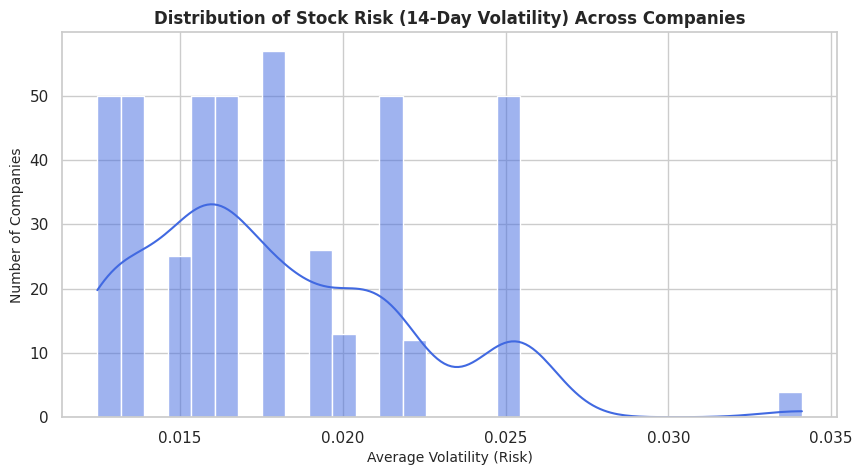

In [ ]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
avg_volatility = master_df.groupby("Name")["Volatility_14d"].mean().reset_index()
sns.histplot(avg_volatility["Volatility_14d"], bins=30, kde=True, color="royalblue")
plt.title("Distribution of Stock Risk (14-Day Volatility) Across Companies", fontsize=12, fontweight="bold")
plt.xlabel("Average Volatility (Risk)", fontsize=10)
plt.ylabel("Number of Companies", fontsize=10)
plt.show()

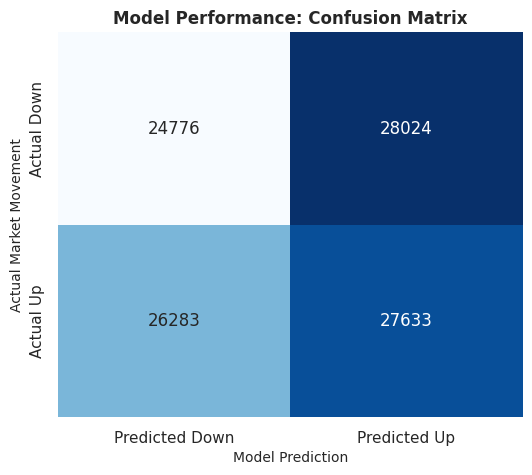

In [ ]:

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Down", "Predicted Up"],
            yticklabels=["Actual Down", "Actual Up"])
plt.title("Model Performance: Confusion Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Model Prediction", fontsize=10)
plt.ylabel("Actual Market Movement", fontsize=10)
plt.show()

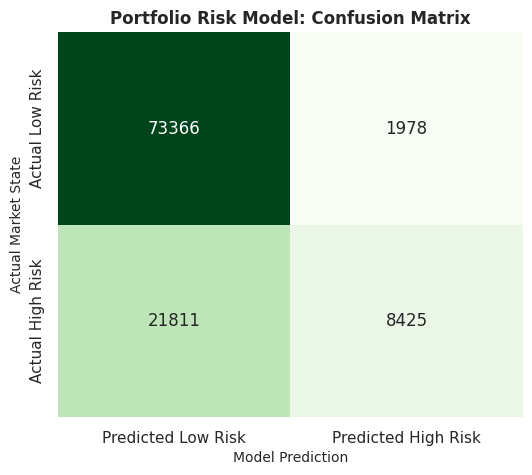

In [ ]:
risk_cm = confusion_matrix(y_test_risk, risk_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(risk_cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["Predicted Low Risk", "Predicted High Risk"],
            yticklabels=["Actual Low Risk", "Actual High Risk"])
plt.title("Portfolio Risk Model: Confusion Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Model Prediction", fontsize=10)
plt.ylabel("Actual Market State", fontsize=10)
plt.show()

<Figure size 700x500 with 0 Axes>

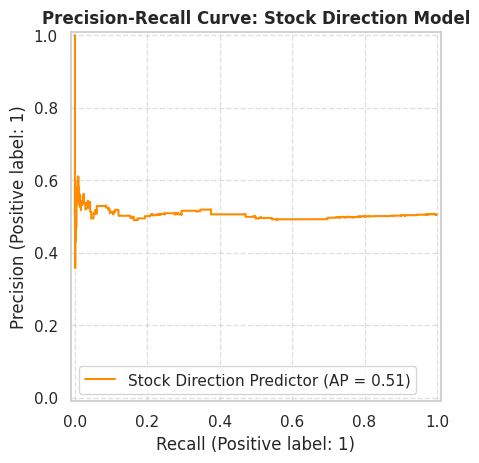

In [ ]:
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, name="Stock Direction Predictor", color="darkorange"
)
plt.title("Precision-Recall Curve: Stock Direction Model", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

<Figure size 700x500 with 0 Axes>

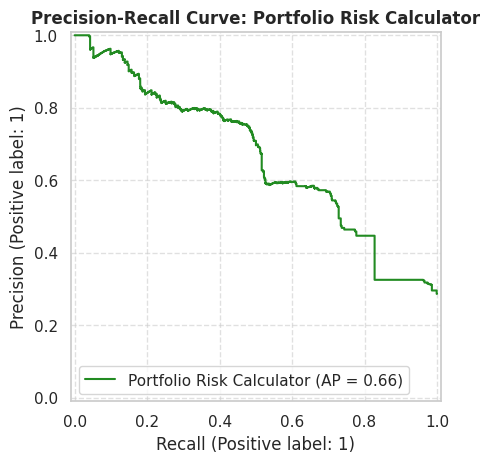

In [ ]:
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_estimator(
    risk_model, X_test_risk, y_test_risk, name="Portfolio Risk Calculator", color="forestgreen"
)
plt.title("Precision-Recall Curve: Portfolio Risk Calculator", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

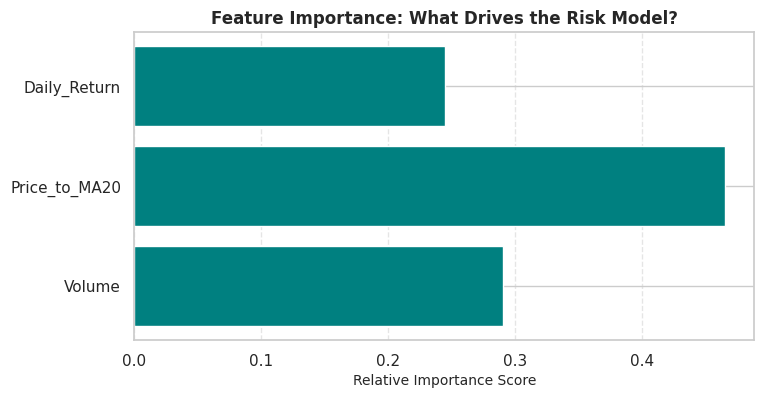

In [ ]:
importances = risk_model.feature_importances_
feat_names = risk_features  # was hardcoded and mismatched before

plt.figure(figsize=(8, 4))
plt.barh(feat_names, importances, color="teal")
plt.title("Feature Importance: What Drives the Risk Model?", fontsize=12, fontweight="bold")
plt.xlabel("Relative Importance Score", fontsize=10)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

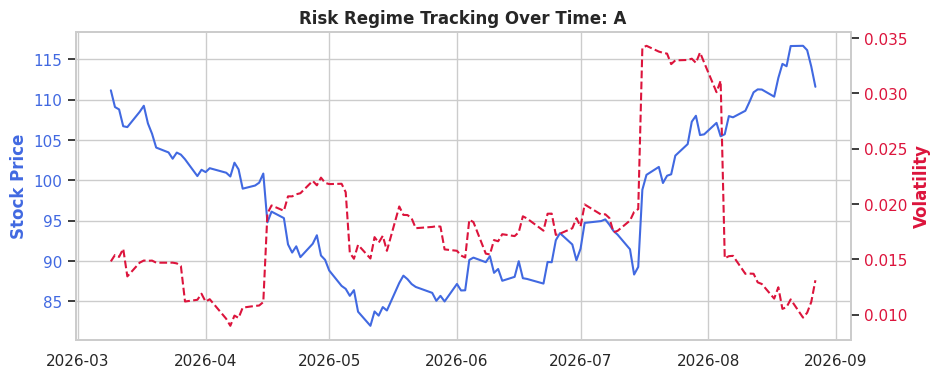

In [ ]:
sample_name = master_df["Name"].unique()[0]
sample_df = master_df[master_df["Name"] == sample_name].tail(120)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(sample_df["Date"], sample_df["Close"], color="royalblue", label="Close Price", linewidth=1.5)
ax1.set_ylabel("Stock Price", color="royalblue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="royalblue")

ax2 = ax1.twinx()
ax2.plot(sample_df["Date"], sample_df["Volatility_14d"], color="crimson", linestyle="--", label="14d Volatility (Risk)", linewidth=1.5)
ax2.set_ylabel("Volatility", color="crimson", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="crimson")

plt.title(f"Risk Regime Tracking Over Time: {sample_name}", fontsize=12, fontweight="bold")
plt.grid(False)
plt.show()

In [ ]:
csv_files = glob.glob("*.csv")
print(f"Total CSV files found: {len(csv_files)}")
print(master_df.shape)

Total CSV files found: 437
(533577, 16)


In [ ]:

with open("stock_direction_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("portfolio_risk_model.pkl", "wb") as f:
    pickle.dump(risk_model, f)

print("Both models successfully saved as .pkl files!")


Both models successfully saved as .pkl files!


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error
)
import numpy as np

# Get binary predictions and model confidence probabilities for class 1 (High Risk)
risk_preds = risk_model.predict(X_test_risk)
risk_probs = risk_model.predict_proba(X_test_risk)[:, 1]

# Core classification metrics
acc = accuracy_score(y_test_risk, risk_preds)
prec = precision_score(y_test_risk, risk_preds, zero_division=0)
rec = recall_score(y_test_risk, risk_preds, zero_division=0)
f1 = f1_score(y_test_risk, risk_preds, zero_division=0)

# Error metrics evaluating probability confidence against actual 0/1 outcomes
mae = mean_absolute_error(y_test_risk, risk_probs)
rmse = np.sqrt(mean_squared_error(y_test_risk, risk_probs))

print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")
print(f"MAE:       {mae:.4f}")
print(f"RMSE:      {rmse:.4f}")

Accuracy:  77.47%
Precision: 80.99%
Recall:    27.86%
F1 Score:  41.46%
MAE:       0.2973
RMSE:      0.4035
